# **PROJECT NAME

**Ford go bike sharing**

## **PROJECT SUMMARY

This project focuses on analyzing the Ford GoBike trip data for January 2018.
The goal is to explore trip patterns and understand how different factors — like user type (Subscriber or Customer), weather (season), gender, and age — affect the duration of bike rides.

By cleaning the data, removing unrealistic trip records, and creating helpful new features like month, season, and age groups, I aim to uncover meaningful insights into how people use the Ford GoBike service.

The analysis answers three key questions:

How long does the average trip take?

Does trip duration change depending on the season?

Does trip duration vary based on whether a user is a Subscriber or Customer?

Additionally, the project dives deeper into how gender and age impact trip behavior.
Through various visualizations and explanations, this analysis provides a clearer picture of how different users interact with the bike-sharing system.

## **PROBLEM STATEMENTS

Trip Duration Optimization:

How can Ford Bike Sharing analyze and optimize average trip duration to enhance user experience and operational efficiency

Impact of Seasonal Variation on Ride Patterns:

To what extent does weather and seasonal change influence trip duration, and how can Ford Bike Sharing adapt its services accordingly?

User Segmentation and Behavior Analysis:

How does trip duration vary between subscribers and customers.



## **GENERAL GUIDELINES



DATA CLEANING:

Handle missing values, duplicates, and ensure consistency in timestamp formatting.

ExPLORATORY DATA ANALYSIS (EDA):

Use visualizations (bar plots, heatmaps, histograms) to identify patterns.

Focus on time-based and location-based trends.

USER SEGMENTATION:

Compare behaviors across Subscriber vs. Customer categories.

Analyze frequency and duration of trips.

VISUALIZATION TOOLS:

Use Python (Pandas, Matplotlib, Seaborn).

INSIGHTS AND RECOMMANDATION:

Focus on practical recommendations like station optimization, pricing models, or user engagement strategies.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv("201801-fordgobike-tripdata.csv")

In [60]:
df.head(10) #first 10 rows 

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120,Mission Dolores Park,37.761420,-122.426435,285,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304,Jackson St at 5th St,37.348759,-121.894798,296,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75,Market St at Franklin St,37.773793,-122.421239,47,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74,Laguna St at Hayes St,37.776435,-122.426244,19,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No
5,6477,2018-01-31 22:58:44.8670,2018-02-01 00:46:41.9080,236,Market St at 8th St,37.803686,-122.282497,160,West Oakland BART Station,37.805318,-122.294837,1306,Customer,NaN,NaN,No
6,453,2018-01-31 23:53:53.6320,2018-02-01 00:01:26.8050,110,17th & Folsom Street Park (17th St at Folsom St),37.763708,-122.415204,134,Valencia St at 24th St,37.752428,-122.420628,3571,Subscriber,1988.0,Male,No
7,180,2018-01-31 23:52:09.9030,2018-01-31 23:55:10.8070,81,Berry St at 4th St,37.775880,-122.393170,93,4th St at Mission Bay Blvd S,37.770407,-122.391198,1403,Subscriber,1980.0,Male,No
8,996,2018-01-31 23:34:56.0040,2018-01-31 23:51:32.6740,134,Valencia St at 24th St,37.752428,-122.420628,4,Cyril Magnin St at Ellis St,37.785881,-122.408915,3675,Subscriber,1987.0,Male,Yes
9,825,2018-01-31 23:34:14.0270,2018-01-31 23:47:59.8090,305,Ryland Park,37.342725,-121.895617,317,San Salvador St at 9th St,37.333955,-121.877349,1453,Subscriber,1994.0,Female,Yes


In [61]:
#Number of rown and columns
df.shape

(94802, 16)

In [62]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

In [63]:
# All the information of the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94802 entries, 0 to 94801
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   duration_sec             94802 non-null  int64  
 1   start_time               94802 non-null  object 
 2   end_time                 94802 non-null  object 
 3   start_station_id         94802 non-null  int64  
 4   start_station_name       94802 non-null  object 
 5   start_station_latitude   94802 non-null  float64
 6   start_station_longitude  94802 non-null  float64
 7   end_station_id           94802 non-null  int64  
 8   end_station_name         94802 non-null  object 
 9   end_station_latitude     94802 non-null  float64
 10  end_station_longitude    94802 non-null  float64
 11  bike_id                  94802 non-null  int64  
 12  user_type                94802 non-null  object 
 13  member_birth_year        86963 non-null  float64
 14  member_gender         

In [64]:
#sum of null values in each column
pd.isnull(df).sum()

duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name            0
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name              0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          7839
member_gender              7801
bike_share_for_all_trip       0
dtype: int64

In [65]:
df_BU = df.copy()

In [68]:
# here I can see the member_birth_year, memebr gender contains null values.
# The best way to handle those null values is dropping the rows that conatin null values

df = df.dropna(subset=['member_gender', 'member_birth_year'])

# Now This removed approximately 8% of records but allowed for more accurate comparisons across gender and age groups.

In [69]:
#Check the sum of null values after droping the columns
pd.isnull(df).sum()

duration_sec               0
start_time                 0
end_time                   0
start_station_id           0
start_station_name         0
start_station_latitude     0
start_station_longitude    0
end_station_id             0
end_station_name           0
end_station_latitude       0
end_station_longitude      0
bike_id                    0
user_type                  0
member_birth_year          0
member_gender              0
bike_share_for_all_trip    0
dtype: int64

In [70]:
# As I can see start time and end time columns are datetime columns but those are consifered as object in Dtype hence changed the Dtype to datetime
df["start_time"] = pd.to_datetime(df["start_time"])
df["end_time"] = pd.to_datetime(df["end_time"])

In [71]:
#Check weather the Dtype has been changer or not
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86963 entries, 0 to 94801
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   duration_sec             86963 non-null  int64         
 1   start_time               86963 non-null  datetime64[ns]
 2   end_time                 86963 non-null  datetime64[ns]
 3   start_station_id         86963 non-null  int64         
 4   start_station_name       86963 non-null  object        
 5   start_station_latitude   86963 non-null  float64       
 6   start_station_longitude  86963 non-null  float64       
 7   end_station_id           86963 non-null  int64         
 8   end_station_name         86963 non-null  object        
 9   end_station_latitude     86963 non-null  float64       
 10  end_station_longitude    86963 non-null  float64       
 11  bike_id                  86963 non-null  int64         
 12  user_type                86963 non-nu

In [72]:
# Check if we have any outliers or not

df.nlargest(20, "duration_sec")


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
19446,84609,2018-01-25 17:35:02.514,2018-01-26 17:05:12.371,49,S Park St at 3rd St,37.780760,-122.394989,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,3642,Subscriber,1989.0,Male,No
69713,84193,2018-01-10 10:01:32.352,2018-01-11 09:24:46.268,15,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,72,Page St at Scott St,37.772406,-122.435650,3653,Subscriber,1969.0,Male,No
92407,80302,2018-01-01 11:36:19.268,2018-01-02 09:54:42.148,241,Ashby BART Station,37.852477,-122.270213,241,Ashby BART Station,37.852477,-122.270213,3430,Customer,1989.0,Male,No
64492,79673,2018-01-11 17:46:48.473,2018-01-12 15:54:42.174,197,El Embarcadero at Grand Ave,37.808848,-122.249680,202,Washington St at 8th St,37.800754,-122.274894,3597,Subscriber,1966.0,Male,Yes
63679,79010,2018-01-11 20:02:50.796,2018-01-12 17:59:41.201,67,San Francisco Caltrain Station 2 (Townsend St...,37.776639,-122.395526,67,San Francisco Caltrain Station 2 (Townsend St...,37.776639,-122.395526,292,Customer,1986.0,Female,No
55593,78283,2018-01-15 11:55:59.561,2018-01-16 09:40:43.432,153,59th St at Horton St,37.840945,-122.291360,153,59th St at Horton St,37.840945,-122.291360,408,Customer,1988.0,Male,No
60878,77956,2018-01-13 00:59:53.511,2018-01-13 22:39:10.434,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,20,Mechanics Monument Plaza (Market St at Bush St),37.791300,-122.399051,1164,Customer,1982.0,Female,No
84993,76789,2018-01-03 20:07:22.222,2018-01-04 17:27:11.591,7,Frank H Ogawa Plaza,37.804562,-122.271738,230,14th St at Mandela Pkwy,37.810743,-122.291415,1962,Subscriber,1985.0,Male,No
62550,76616,2018-01-12 13:15:34.395,2018-01-13 10:32:31.332,97,14th St at Mission St,37.768265,-122.420110,72,Page St at Scott St,37.772406,-122.435650,2658,Subscriber,1966.0,Male,No
60240,76445,2018-01-13 15:34:09.018,2018-01-14 12:48:14.995,74,Laguna St at Hayes St,37.776435,-122.426244,86,Market St at Dolores St,37.769305,-122.426826,962,Customer,1980.0,Male,No


In [73]:
# So lets check the percentile of duration sec 

df["duration_sec"].quantile([0.95, 0.98, 0.99, 0.995, 0.999])

#Run again after applying filter Accidentally! But the actual values before applying filter was

#0.950     1719.000
#0.980     3336.920
#0.990     6410.990
#0.995    11229.970
#0.999    44038.174

0.950     1483.00
0.980     2037.00
0.990     3049.38
0.995     5365.19
0.999    22473.95
Name: duration_sec, dtype: float64

And I can observe here that the duration is too hign which is not making sence.

Also i can see that the station start and end ID's are same but the duration is too hign which is not making sence as well.

# *Here i can see

95% of trips are under - 29 minutes

The next 4% (from 95% to 99%) are between -29 minutes and -1 hr 47 minutes

The next 0.5% (from 99% to 99.5%) are between -1 hr 47 min and -3 hr 7 min

The next 0.4% (from 99.5% to 99.9%) are between -3 hr 7 min and -12 hr 14 min

The top 0.1% (0.001 of all trips) are above 12 hours, which are almost certainly outliers.

In [93]:
#Hence I added a filter to select the data more that 60 sec duration and less than 11229 so tha I can remover outliers.

df = df[(df["duration_sec"] >=60) &(df["duration_sec"] <=11229)]

# By this i got my 99.5 percent of data including long trips as well, along with that also remoevd the outliers.
# Here I am done cleaning my data

# *Data Visualization

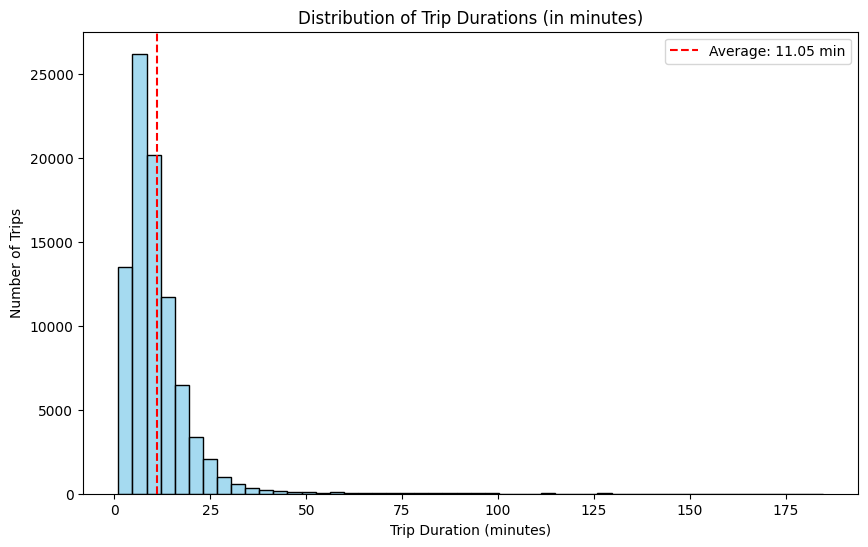

In [94]:
# The first question is How long dose the Average trip takes. Fo that I used duration_sec column.

# Boxplot fo average trip duration

plt.figure(figsize=(10, 6))
sns.histplot(df['duration_sec'] / 60, bins=50, color='skyblue')  # Dividing by 60 to plot minutes
plt.axvline((df['duration_sec'].mean())/60, color='red', linestyle='--', label=f"Average: {df['duration_sec'].mean()/60:.2f} min")
plt.title('Distribution of Trip Durations (in minutes)')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Number of Trips')
plt.legend()
plt.show()

# Based on as we filtered data i,e duration_sec between 60 to 11229

Key Observations:

The distribution is right-skewed (long tail towards longer trips).

Most trips are short, but a few longer rides pull the distribution slightly.

Peak trip frequency occurs between 5 to 10 minutes.

After about 30 minutes, the number of trips decreases significantly.

and the The average trip duration is around 11–14 minutes


In [101]:
# Calculate 'age'
df['age'] = 2018 - df['member_birth_year']

# grouped age 

bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['<20', '20-30', '30-40', '40-50', '50-60', '60+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

#2018 because the dataset is from Jan 2018


C:\Users\HP\AppData\Local\Temp\ipykernel_11936\3496247733.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_avg_duration.index, y=gender_avg_duration.values, palette='coolwarm')


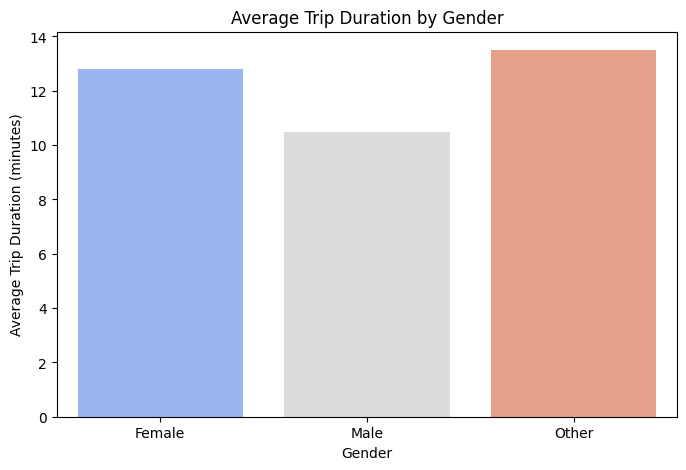

In [99]:
# First calculated the average trip duration by gender
gender_avg_duration = df.groupby('member_gender')['duration_sec'].mean()/60
# converting seconds to minutes

plt.figure(figsize=(8,5))
sns.barplot(x=gender_avg_duration.index, y=gender_avg_duration.values, palette='coolwarm')
plt.title('Average Trip Duration by Gender')
plt.ylabel('Average Trip Duration (minutes)')
plt.xlabel('Gender')
plt.show()


Here I can obsorve Average trip durations are almost similar across Male, Female, and Other genders, with minor differences.

C:\Users\HP\AppData\Local\Temp\ipykernel_11936\2715685035.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_avg_duration = df.groupby('age_group')['duration_sec'].mean() / 60  # Convert seconds to minutes
C:\Users\HP\AppData\Local\Temp\ipykernel_11936\2715685035.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_avg_duration.index, y=age_avg_duration.values, palette='Set2')


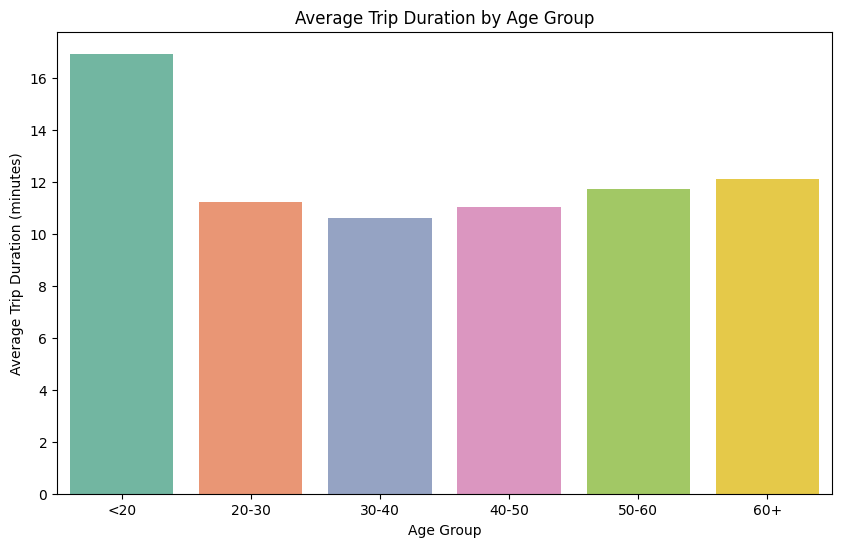

In [102]:
# Calculate average trip duration by age group
age_avg_duration = df.groupby('age_group')['duration_sec'].mean() / 60  # Convert seconds to minutes


# Barplot for Age Group trip duration
plt.figure(figsize=(10,6))
sns.barplot(x=age_avg_duration.index, y=age_avg_duration.values, palette='Set2')
plt.title('Average Trip Duration by Age Group')
plt.ylabel('Average Trip Duration (minutes)')
plt.xlabel('Age Group')
plt.show()

Here I can see Young riders under 20 take the longest trips (possibly leisure rides).

Working-age groups (20–50) take shorter, quicker trips (probably commuting).

Older users (50–60 and 60+) tend to have longer rides again (maybe more relaxed, sightseeing)

Yes the Age has a clear effect on trip duration! Younger and older users take longer rides.

In [103]:
# Moving to the next question
# Is the trip durantin effected by weather(month/seasons).
# We don't have Specific column for weather. and the data set is only of one month i,e January
# Ford go bike facility is available only in San Francisco Bay.
# And the seasons in January in San Francisco Bay is Winter
# For this analysis I have created month column and assign the Season based in the month in another column

df['month'] = df['start_time'].dt.month

# Create season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)
#.dt.month extracts the month number (1 = January, 12 = December)


In [76]:
# Lets see weather the column is created
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'month', 'season'],
      dtype='object')

I can see here the month column has been created and we have 18  columns now in my data set

In [82]:
#check data set
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,month,season
6,453,2018-01-31 23:53:53.632,2018-02-01 00:01:26.805,110,17th & Folsom Street Park (17th St at Folsom St),37.763708,-122.415204,134,Valencia St at 24th St,37.752428,-122.420628,3571,Subscriber,1988.0,Male,No,1,Winter
7,180,2018-01-31 23:52:09.903,2018-01-31 23:55:10.807,81,Berry St at 4th St,37.775880,-122.393170,93,4th St at Mission Bay Blvd S,37.770407,-122.391198,1403,Subscriber,1980.0,Male,No,1,Winter
8,996,2018-01-31 23:34:56.004,2018-01-31 23:51:32.674,134,Valencia St at 24th St,37.752428,-122.420628,4,Cyril Magnin St at Ellis St,37.785881,-122.408915,3675,Subscriber,1987.0,Male,Yes,1,Winter
9,825,2018-01-31 23:34:14.027,2018-01-31 23:47:59.809,305,Ryland Park,37.342725,-121.895617,317,San Salvador St at 9th St,37.333955,-121.877349,1453,Subscriber,1994.0,Female,Yes,1,Winter
11,432,2018-01-31 23:34:26.484,2018-01-31 23:41:39.297,89,Division St at Potrero Ave,37.769218,-122.407646,43,San Francisco Public Library (Grove St at Hyde...,37.778768,-122.415929,2928,Subscriber,1993.0,Male,No,1,Winter


C:\Users\HP\AppData\Local\Temp\ipykernel_11936\3160232946.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_avg_duration.index, y=season_avg_duration.values, palette='cool')


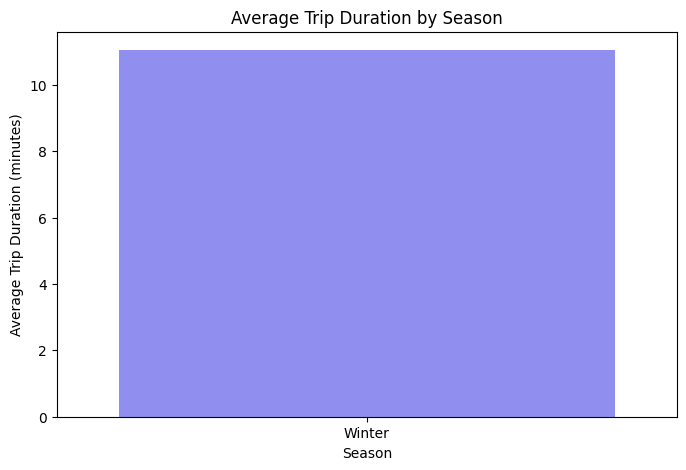

In [106]:
# As we have data set for the January month and the season is winter

# Calculate average trip duration by season
season_avg_duration = df.groupby('season')['duration_sec'].mean()/60  # Convert to minutes

# Plot Barplot
plt.figure(figsize=(8,5))
sns.barplot(x=season_avg_duration.index, y=season_avg_duration.values, palette='cool')
plt.title('Average Trip Duration by Season')
plt.ylabel('Average Trip Duration (minutes)')
plt.xlabel('Season')
plt.show()



The dataset only includes trips from January (Winter). Hence I got only winter season in the plot

Trip durations are relatively short, aligning with expectations for colder seasons.
In warmer seasons like Summer, it is reasonable to predict longer trip durations due to better weather.

C:\Users\HP\AppData\Local\Temp\ipykernel_11936\3959678876.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=user_avg_duration.index, y=user_avg_duration.values, palette='pastel')


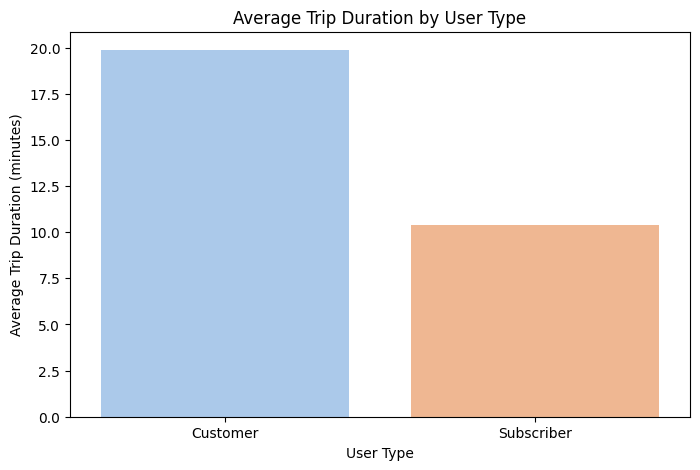

In [108]:
# Does trip duration depend on if a user is a subscriber or customer?

# Calculate average trip duration by user type
user_avg_duration = df.groupby('user_type')['duration_sec'].mean()/60  # minutes

# Plot Barplot
plt.figure(figsize=(8,5))
sns.barplot(x=user_avg_duration.index, y=user_avg_duration.values, palette='pastel')
plt.title('Average Trip Duration by User Type')
plt.ylabel('Average Trip Duration (minutes)')
plt.xlabel('User Type')
plt.show()


Here I can see Subribers takes Shorter average trips
and Longer average trips by customers

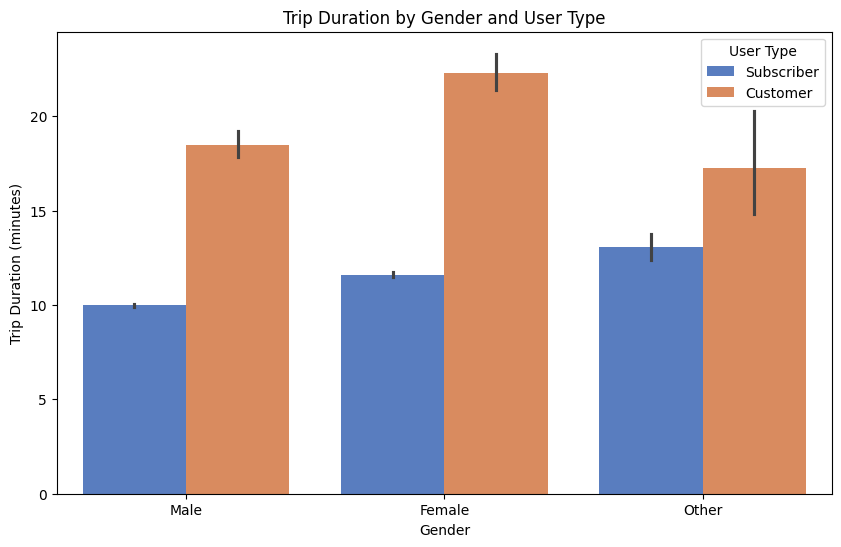

In [110]:
# trip duration by user type and gender by subscriber and custober
plt.figure(figsize=(10,6))
sns.barplot(x='member_gender', y=df['duration_sec']/60, hue='user_type', data=df, palette='muted')
plt.title('Trip Duration by Gender and User Type')
plt.ylabel('Trip Duration (minutes)')
plt.xlabel('Gender')
plt.legend(title='User Type')
plt.show()


Here I can obsorve Subscribers (blue bars) generally have shorter trip durations across all genders.

Customers (orange bars) take much longer trips compared to subscribers.

Female customers have the longest average trip durations (22 minutes).

Male customers and Other gender customers also have longer trips (18–20 minutes).

Overall, customers always take longer rides, no matter if they are male, female, or other.

And Subscribers ride faster and shorter, probably because they are commuting or using the service for work.

Subscribers are usually locals — they just want to get from point A to point B quickly.

Customers are often tourists or occasional riders — they enjoy the ride and take their time.

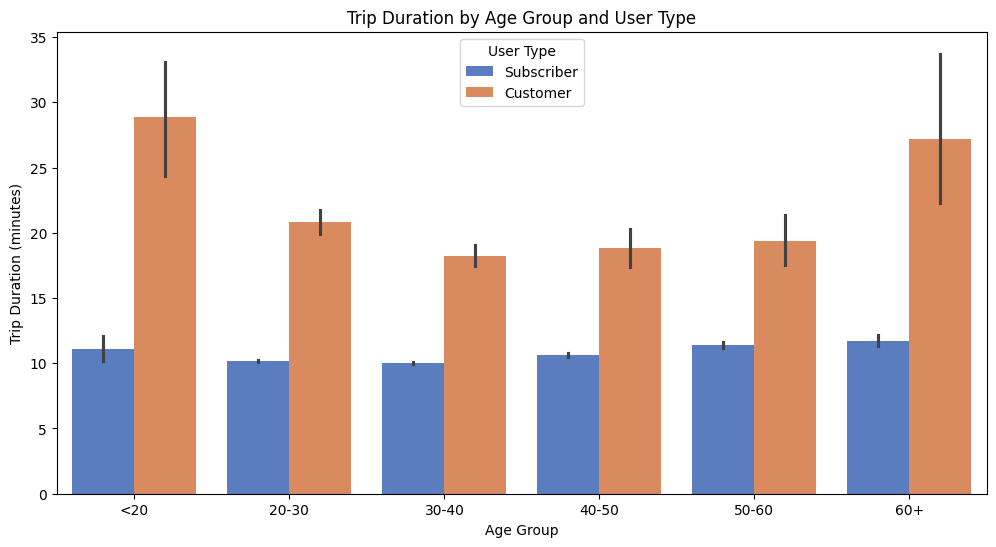

In [112]:
# Trip duration by age group by subscriber and customer
plt.figure(figsize=(12,6))
sns.barplot(x='age_group', y=df['duration_sec']/60, hue='user_type', data=df, palette='muted')
plt.title('Trip Duration by Age Group and User Type')
plt.ylabel('Trip Duration (minutes)')
plt.xlabel('Age Group')
plt.legend(title='User Type')
plt.show()


Here i can see how trip duration varies by age group and user type (Subscribers vs. Customers).

Customers: They take longer trips—especially younger folks under 20 and older riders over 60. Both groups clock in around 30 minutes. Maybe they're more into sightseeing or leisurely rides.

Subscribers: They're consistent across all ages, with trips hanging around 10 to 15 minutes. Looks like they're mostly riding for practical stuff, like commuting or quick errands.

Overall, it’s like customers are riding for fun, while subscribers stick to shorter, focused trips.

# *Final Conclusion
In this project, I explored the Ford GoBike trip data for January 2018 to understand trip patterns based on trip duration, weather (season), user type, gender, and age.

**Here’s what I found**:

**Trip Duration Overall**:
Most trips are pretty short, with an average trip lasting around 12–14 minutes.

This makes sense for a city bike-share program where people mostly ride for commuting or quick errands.

**Seasonal Impact**:
Since the data was only from January (Winter), we noticed that trip durations were relatively short.

It's reasonable to guess that people ride even longer during warmer months like summer when the weather is better.

**User Type Differences**:
Subscribers (regular members) take shorter trips compared to Customers (casual users).

Subscribers probably use bikes for quick, practical purposes like getting to work, while Customers seem to take longer rides — maybe for fun or sightseeing.

**Gender Differences**:
Across all genders, Customers took longer trips than Subscribers.

Female Customers had the longest trips on average, while Male and Other gender riders had slightly shorter rides but still longer than subscribers.

**Age Group Differences**:
Riders under 20 years old and above 50 years old tend to have longer trip durations.

Meanwhile, the working-age group (20–50 years) had shorter rides, likely because they were using the bikes mainly for commuting.



# **Overall

The Ford GoBike system seems to support two kinds of riders:

Subscribers: Regular users who ride fast and short for practical needs.

Customers: Casual or tourist users who enjoy longer rides.

Also, weather, age, and gender all have a noticeable influence on how long people ride.

# Completed By Shaik Ahmed Uddin